# Introduction

Looking at selected matched cell types in human and mouse samples, transcribed regions were lifted over.

In these matched mouse and human sample types, the halLiftover was performed reciprocally.


# Load libraries

In [1]:
library(data.table)
library(ggplot2)
library(cowplot)
library(pheatmap)
library(RColorBrewer)

# Import data

## Counts

In [2]:
mm10_norm_counts <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc/mm10/processed_data/counts/normalized/gene_bidir_tpm.tsv.gz")
dim(mm10_norm_counts)
tail(mm10_norm_counts, 3)

[1] 706917    756

chrom,start,stop,gene_transcript,score,strand,SRR8364243,SRR8364244,SRR8364245,SRR8364246,⋯,SRZ7184276,SRZ7184278,SRZ7184280,SRZ7184282,SRR5144955,SRR5144956,SRR5144957,SRR5144958,SRZ12179472,SRZ12179474
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chrY,90828615,90828811,chrY:90828615-90828811,40,.,22.96989,31.5495,19.83703,28.40446,⋯,0,0,0,0,0,0,1.790591,0,0,0
chrY,90830134,90830562,chrY:90830134-90830562,69,.,0.00000,0.0000,0.00000,0.00000,⋯,0,0,0,0,0,0,0.000000,0,0,0
chrY,90830562,90831000,chrY:90830562-90831000,69,.,0.00000,0.0000,0.00000,0.00000,⋯,0,0,0,0,0,0,0.000000,0,0,0


In [3]:
hg38_norm_counts <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/counts/normalized_counts/gene_bidir_tpm.tsv.gz")
dim(hg38_norm_counts)
tail(hg38_norm_counts, 3)

[1] 876410   1651

chrom,start,stop,gene_transcript,score,strand,SRR7266931,SRR7266932,SRR7266933,SRR7266934,⋯,SRR3713716,SRR3713717,SRR3713718,SRR3713719,SRR8483105,SRR8483106,SRR8483107,SRR8483108,SRR8483109,SRR8483110
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chrY,25633930,25634690,chrY:25633930-25634690,1,.,0.0000000,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chrY,25639750,25640170,chrY:25639750-25640170,1,.,0.0000000,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chrY,25738260,25738790,chrY:25738260-25738790,1,.,0.1481851,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


# Functions

## Get filtered bidirectional regions by TPMs

In [4]:
samples_by_cell_counts <- function(counts_dt, sample_id, min_tpm=1){
    
    #get a vector of columns to use
    col_vector <- c("chrom", "start", "stop",
                    "gene_transcript", sample_id)
    
    #get sample counts including the coordinates
    sample_tpms <- counts_dt[,..col_vector]
    print(head(sample_tpms))
    
    #pull out only the bidirectional region
    sample_tpms_bidir <- sample_tpms[grepl("^chr",
                                           sample_tpms$gene_transcript),]

    # filter only transcribed bidirectional regions
    sample_tpms_bidir_txpd <- sample_tpms_bidir[ which(sample_tpms_bidir[[sample_id]] > min_tpm),]
  
    return(sample_tpms_bidir_txpd)
}

## Load liftOver bed files

In [5]:
load_liftOver <- function(path_list, human2mouse = TRUE, chromosome_run=TRUE){
    
    if (chromosome_run == TRUE) {
        lift_dir <- path_list

        lift_files <- list.files(path=lift_dir,
                             pattern="lifted.sorted.bed",
                                    recursive = TRUE,
                             full.names=TRUE)
        ##load all files 
        lift_list <- lapply(lift_files,
                           data.table::fread,
                           nThread = 8) 
        lift_DT <- do.call(rbind, lift_list)
        
        } else {
        
        lift_DT <- data.table::fread(path_list)
    }
    
    if (human2mouse == TRUE) {
        
        # add column names
        colnames(lift_DT) <- c('mm10_chrom','mm10_start','mm10_end',
                               'empty_col','hg38_bidir_id')
        # get coordinates for each genome region
        lift_DT$hg38_chrom <- as.character(lapply(strsplit(lift_DT$hg38_bidir_id, 
                                                                  '_'), 
                                                         `[`, 1))
        lift_DT$hg38_start <- as.numeric(as.character(lapply(strsplit(lift_DT$hg38_bidir_id, 
                                                                  '_'), 
                                                         `[`, 2)))
        lift_DT$hg38_end <- as.numeric(as.character(lapply(strsplit(lift_DT$hg38_bidir_id, 
                                                                  '_'), 
                                                         `[`, 3)))
        } else {
        
        colnames(lift_DT) <- c('hg38_chrom','hg38_start','hg38_end',
                               'empty_col','mm10_bidir_id')
        # get coordinates for each genome region
        lift_DT$mm10_chrom <- as.character(lapply(strsplit(lift_DT$mm10_bidir_id, 
                                                                  '_'), 
                                                         `[`, 1))
        lift_DT$mm10_start <- as.numeric(as.character(lapply(strsplit(lift_DT$mm10_bidir_id, 
                                                                  '_'), 
                                                         `[`, 2)))
        lift_DT$mm10_end <- as.numeric(as.character(lapply(strsplit(lift_DT$mm10_bidir_id, 
                                                                  '_'), 
                                                         `[`, 3)))
    }
    
    # calculate region widths for lifted over mouse regions
    lift_DT$mm10_width <- lift_DT$mm10_end - lift_DT$mm10_start
    lift_DT$hg38_width <- lift_DT$hg38_end - lift_DT$hg38_start
    lift_DT$width_difference <- lift_DT$hg38_width - lift_DT$mm10_width
    
    return(lift_DT)
    
}

# Sample regions by animal and tissue

## ESC
### Mouse TPMs

In [7]:
#get sample counts including the coordinates
esc_mouse <- mm10_norm_counts[,c("chrom", "start", "stop",
                                 "gene_transcript","SRZ7741177")]
head(esc_mouse, 3)

chrom,start,stop,gene_transcript,SRZ7741177
<chr>,<int>,<int>,<chr>,<dbl>
chr1,3214481,3670748,Xkr4:NM_001011874.1,0.006807986
chr1,4343506,4359564,Rp1:NM_011283.2,0.000000000
chr1,4490927,4496604,Sox17:NM_011441.5,1.284426296


In [8]:
#pull out only the bidirectional region
esc_mouse_bidir <- esc_mouse[grepl("^chr",esc_mouse$gene_transcript),]
dim(esc_mouse_bidir)
head(esc_mouse_bidir, 3)
tail(esc_mouse_bidir, 3)

[1] 680735      5

chrom,start,stop,gene_transcript,SRZ7741177
<chr>,<int>,<int>,<chr>,<dbl>
chr1,6234,6612,chr1:6234-6612,0
chr1,6855,7341,chr1:6855-7341,0
chr1,7420,8220,chr1:7420-8220,0


chrom,start,stop,gene_transcript,SRZ7741177
<chr>,<int>,<int>,<chr>,<dbl>
chrY,90828615,90828811,chrY:90828615-90828811,14.39673
chrY,90830134,90830562,chrY:90830134-90830562,0.00000
chrY,90830562,90831000,chrY:90830562-90831000,0.00000


In [9]:
# filter only transcribed bidirectional regions
esc_mouse_bidir_txpd <- subset(esc_mouse_bidir, SRZ7741177 > 1)
dim(esc_mouse_bidir_txpd)
head(esc_mouse_bidir_txpd)

[1] 95127     5

chrom,start,stop,gene_transcript,SRZ7741177
<chr>,<int>,<int>,<chr>,<dbl>
chr1,3058959,3059139,chr1:3058959-3059139,2.984642
chr1,3063280,3063628,chr1:3063280-3063628,1.354420
chr1,3953631,3953915,chr1:3953631-3953915,6.160406
chr1,3986905,3987123,chr1:3986905-3987123,3.391793
chr1,3987267,3987667,chr1:3987267-3987667,1.683978
chr1,4085669,4085853,chr1:4085669-4085853,1.095041


In [10]:
data.table::fwrite(esc_mouse_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/ESC/mm10_esc_SRZ7741177_transcribed_over1tpm.bed",
                  sep='\t', col.names=FALSE)

### Human TPMs

In [11]:
#get sample counts including the coordinates
esc_human <- hg38_norm_counts[,c("chrom", "start", "stop",
                                 "gene_transcript","SRR10669536")]
head(esc_human, 3)

chrom,start,stop,gene_transcript,SRR10669536
<chr>,<int>,<int>,<chr>,<dbl>
chr1,12623,14409,DDX11L1:NR_046018.2,0.0000000
chr1,14361,28620,WASH7P:NR_024540.1,0.3358665
chr1,17368,17436,MIR6859-1:NR_106918.1,0.0000000


In [12]:
#pull out only the bidirectional region
esc_human_bidir <- esc_human[grepl("^chr",esc_human$gene_transcript),]
dim(esc_human_bidir)
head(esc_human_bidir, 3)
tail(esc_human_bidir, 3)

[1] 847521      5

chrom,start,stop,gene_transcript,SRR10669536
<chr>,<int>,<int>,<chr>,<dbl>
chr1,12182,12456,chr1:12182-12456,0.0000000
chr1,13264,13506,chr1:13264-13506,4.2235069
chr1,14655,14811,chr1:14655-14811,0.7263356


chrom,start,stop,gene_transcript,SRR10669536
<chr>,<int>,<int>,<chr>,<dbl>
chrY,25633930,25634690,chrY:25633930-25634690,0
chrY,25639750,25640170,chrY:25639750-25640170,0
chrY,25738260,25738790,chrY:25738260-25738790,0


In [13]:
# filter only transcribed bidirectional regions
esc_human_bidir_txpd <- subset(esc_human_bidir, SRR10669536 > 1)
dim(esc_human_bidir_txpd)
head(esc_human_bidir_txpd)

[1] 84746     5

chrom,start,stop,gene_transcript,SRR10669536
<chr>,<int>,<int>,<chr>,<dbl>
chr1,13264,13506,chr1:13264-13506,4.223507
chr1,16191,16429,chr1:16191-16429,10.974049
chr1,17453,17621,chr1:17453-17621,4.723330
chr1,181984,182180,chr1:181984-182180,1.157713
chr1,183434,183804,chr1:183434-183804,2.458969
chr1,184081,184293,chr1:184081-184293,5.889115


In [ ]:
#esc_human_bidir_txpd <- samples_by_cell_counts(counts_dt = hg38_norm_counts, 
#                                               sample_id = "SRR10669536",
#                                               min_tpm = 1)

In [14]:
data.table::fwrite(esc_human_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/ESC/hg38_esc_SRR10669536_transcribed_over1tpm.bed",
                  sep='\t', col.names=FALSE)

## CD4+

### Mouse TPMs

In [15]:
cd4_mouse_bidir_txpd <- samples_by_cell_counts(counts_dt = mm10_norm_counts, 
                                               sample_id = "SRR4012429",
                                               min_tpm = 1)
dim(cd4_mouse_bidir_txpd)
head(cd4_mouse_bidir_txpd)

    chrom   start    stop      gene_transcript   SRR4012429
   <char>   <int>   <int>               <char>        <num>
1:   chr1 3214481 3670748  Xkr4:NM_001011874.1 0.0001439843
2:   chr1 4343506 4359564      Rp1:NM_011283.2 0.0000000000
3:   chr1 4490927 4496604    Sox17:NM_011441.5 0.0000000000
4:   chr1 4773197 4784976   Mrpl15:NM_025300.4 0.5688399613
5:   chr1 4808572 4846735   Lypla1:NM_008866.3 0.6790915668
6:   chr1 4859077 4897909 Tcea1:NM_001159751.1 1.1470014529


[1] 65068     5

chrom,start,stop,gene_transcript,SRR4012429
<chr>,<int>,<int>,<chr>,<dbl>
chr1,4893954,4895042,chr1:4893954-4895042,1.598649
chr1,4895042,4895202,chr1:4895042-4895202,1.428162
chr1,4902140,4902420,chr1:4902140-4902420,3.039291
chr1,4903090,4903360,chr1:4903090-4903360,4.969581
chr1,4905902,4907314,chr1:4905902-4907314,3.487019
chr1,4908160,4908470,chr1:4908160-4908470,6.970899


In [17]:
data.table::fwrite(cd4_mouse_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/mm10_cd4_SRR4012429_transcribed_over1tpm.bed",
                  sep='\t',
                   col.names=FALSE)

### Human TPMs

In [18]:
cd4_human_bidir_txpd <- samples_by_cell_counts(counts_dt = hg38_norm_counts, 
                                               sample_id = "SRR4012393",
                                               min_tpm = 1)
dim(cd4_human_bidir_txpd)
head(cd4_human_bidir_txpd)

    chrom start  stop       gene_transcript SRR4012393
   <char> <int> <int>                <char>      <num>
1:   chr1 12623 14409   DDX11L1:NR_046018.2 0.00000000
2:   chr1 14361 28620    WASH7P:NR_024540.1 0.03002498
3:   chr1 17368 17436 MIR6859-1:NR_106918.1 0.00000000
4:   chr1 30365 30503 MIR1302-2:NR_036051.1 0.00000000
5:   chr1 34610 35591   FAM138A:NR_026818.1 0.00000000
6:   chr1 66168 71585  OR4F5:NM_001005484.2 0.00000000


[1] 60711     5

chrom,start,stop,gene_transcript,SRR4012393
<chr>,<int>,<int>,<chr>,<dbl>
chr1,184081,184293,chr1:184081-184293,3.015184
chr1,184403,184641,chr1:184403-184641,3.582897
chr1,186970,187264,chr1:186970-187264,1.209481
chr1,511599,511773,chr1:511599-511773,1.223303
chr1,779711,780005,chr1:779711-780005,3.144650
chr1,787871,788311,chr1:787871-788311,1.618126


In [19]:
data.table::fwrite(cd4_human_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_cd4_SRR4012393_transcribed_over1tpm.bed",
                  sep='\t', col.names=FALSE)


## Hematopoietic projenitor cells

### Mouse TPMs

In [20]:
hpc_mouse_bidir_txpd <- samples_by_cell_counts(counts_dt = mm10_norm_counts, 
                                               sample_id = "SRR930717",
                                               min_tpm = 1)
dim(hpc_mouse_bidir_txpd)
head(hpc_mouse_bidir_txpd)

    chrom   start    stop      gene_transcript  SRR930717
   <char>   <int>   <int>               <char>      <num>
1:   chr1 3214481 3670748  Xkr4:NM_001011874.1 0.00104027
2:   chr1 4343506 4359564      Rp1:NM_011283.2 0.00000000
3:   chr1 4490927 4496604    Sox17:NM_011441.5 0.00000000
4:   chr1 4773197 4784976   Mrpl15:NM_025300.4 5.82893367
5:   chr1 4808572 4846735   Lypla1:NM_008866.3 2.22620458
6:   chr1 4859077 4897909 Tcea1:NM_001159751.1 2.55860577


[1] 57237     5

chrom,start,stop,gene_transcript,SRR930717
<chr>,<int>,<int>,<chr>,<dbl>
chr1,3062489,3062715,chr1:3062489-3062715,1.393955
chr1,3155897,3156227,chr1:3155897-3156227,1.433963
chr1,4528990,4529178,chr1:4528990-4529178,3.348443
chr1,4687923,4688115,chr1:4687923-4688115,2.459284
chr1,4688969,4689477,chr1:4688969-4689477,2.797496
chr1,4714330,4714562,chr1:4714330-4714562,1.358059


In [21]:
data.table::fwrite(hpc_mouse_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/hpc/mm10_hpc_SRR930717_transcribed_over1tpm.bed",
                  sep='\t',
                   col.names=FALSE)

### Human TPMs

In [22]:
hpc_human_bidir_txpd <- samples_by_cell_counts(counts_dt = hg38_norm_counts, 
                                               sample_id = "SRR5508393",
                                               min_tpm = 1)
dim(hpc_human_bidir_txpd)
head(hpc_human_bidir_txpd)

    chrom start  stop       gene_transcript SRR5508393
   <char> <int> <int>                <char>      <num>
1:   chr1 12623 14409   DDX11L1:NR_046018.2  0.0000000
2:   chr1 14361 28620    WASH7P:NR_024540.1  0.6871472
3:   chr1 17368 17436 MIR6859-1:NR_106918.1  0.0000000
4:   chr1 30365 30503 MIR1302-2:NR_036051.1  0.0000000
5:   chr1 34610 35591   FAM138A:NR_026818.1  0.0000000
6:   chr1 66168 71585  OR4F5:NM_001005484.2  0.0000000


[1] 88690     5

chrom,start,stop,gene_transcript,SRR5508393
<chr>,<int>,<int>,<chr>,<dbl>
chr1,13264,13506,chr1:13264-13506,4.480439
chr1,14655,14811,chr1:14655-14811,1.155782
chr1,15084,15360,chr1:15084-15360,1.965247
chr1,16191,16429,chr1:16191-16429,8.351612
chr1,17453,17621,chr1:17453-17621,34.358866
chr1,182662,182874,chr1:182662-182874,4.685529


In [23]:
data.table::fwrite(hpc_human_bidir_txpd,
                   "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/hpc/hg38_hpc_SRR5508393_transcribed_over1tpm.bed",
                  sep='\t', col.names=FALSE)

# Explore liftOver regions

## CD4+

### Human to mouse 

In [24]:
cd4_human2mouse_dir <- "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output"

cd4_human2mouse_files <- list.files(path=cd4_human2mouse_dir,
                         pattern="lifted.sorted.bed",
                                recursive = TRUE,
                         full.names=TRUE)
cd4_human2mouse_files

[1] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr1_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
 [2] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr10_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [3] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr11_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [4] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr12_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [5] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr13_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [6] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr14_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [7] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr15_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [8] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr16_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
 [9] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr17_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[10] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr18_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[11] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr19_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[12] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr2_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[13] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr20_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[14] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr21_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[15] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr22_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed"
[16] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr3_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[17] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr4_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[18] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr5_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[19] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr6_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[20] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr7_bidir_halLiftover/mm10_from_hg38_bidirs.lifted.sorted.bed" 
[21] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/hg38_hal_output/hg38_to_mm10_chr8_bidir_ha

In [25]:
##load all files 
cd4_human2mouse_list <- lapply(cd4_human2mouse_files,
                       data.table::fread,
                       nThread = 8) 

In [26]:
cd4_human2mouse_DT <- do.call(rbind, cd4_human2mouse_list)
colnames(cd4_human2mouse_DT) <- c('mm10_chrom','mm10_start','mm10_end',
                           'empty_col','hg38_bidir_id')
nrow(cd4_human2mouse_DT)
head(cd4_human2mouse_DT)

[1] 55775

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id
<chr>,<int>,<int>,<lgl>,<chr>
chr1,4522845,4522891,NA,chr1_112674565_112674903
chr1,4525405,4525529,NA,chr1_112695450_112695780
chr1,4526004,4526173,NA,chr1_112698060_112698404
chr1,4692346,4692411,NA,chr1_45630542_45630722
chr1,4692452,4692566,NA,chr1_45633535_45633741
chr1,4694487,4694490,NA,chr1_45686418_45686816


In [27]:
# get human coordinates for each hg38 region
cd4_human2mouse_DT$hg38_chrom <- as.character(lapply(strsplit(cd4_human2mouse_DT$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 1))
cd4_human2mouse_DT$hg38_start <- as.numeric(as.character(lapply(strsplit(cd4_human2mouse_DT$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 2)))
cd4_human2mouse_DT$hg38_end <- as.numeric(as.character(lapply(strsplit(cd4_human2mouse_DT$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 3)))
head(cd4_human2mouse_DT, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>
chr1,4522845,4522891,NA,chr1_112674565_112674903,chr1,112674565,112674903
chr1,4525405,4525529,NA,chr1_112695450_112695780,chr1,112695450,112695780
chr1,4526004,4526173,NA,chr1_112698060_112698404,chr1,112698060,112698404


In [28]:
# calculate region widths for lifted over mouse regions
cd4_human2mouse_DT$mm10_width <- cd4_human2mouse_DT$mm10_end - cd4_human2mouse_DT$mm10_start
cd4_human2mouse_DT$hg38_width <- cd4_human2mouse_DT$hg38_end - cd4_human2mouse_DT$hg38_start
cd4_human2mouse_DT$width_difference <- cd4_human2mouse_DT$hg38_width - cd4_human2mouse_DT$mm10_width
head(cd4_human2mouse_DT)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,4522845,4522891,NA,chr1_112674565_112674903,chr1,112674565,112674903,46,338,292
chr1,4525405,4525529,NA,chr1_112695450_112695780,chr1,112695450,112695780,124,330,206
chr1,4526004,4526173,NA,chr1_112698060_112698404,chr1,112698060,112698404,169,344,175
chr1,4692346,4692411,NA,chr1_45630542_45630722,chr1,45630542,45630722,65,180,115
chr1,4692452,4692566,NA,chr1_45633535_45633741,chr1,45633535,45633741,114,206,92
chr1,4694487,4694490,NA,chr1_45686418_45686816,chr1,45686418,45686816,3,398,395


In [29]:
#define the mouse chromosomes
mm10_chroms <- c(paste0("chr",seq(1,19,1)),
                 "chrX","chrY")
mm10_chroms

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chrX"  "chrY"

In [30]:
# get only lift over to main 21 chromosomes
cd4_human2mouse_DT_bidirs <- cd4_human2mouse_DT[cd4_human2mouse_DT$mm10_chrom %in% mm10_chroms,]
dim(cd4_human2mouse_DT_bidirs)
head(cd4_human2mouse_DT_bidirs)

[1] 52219    11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,4522845,4522891,NA,chr1_112674565_112674903,chr1,112674565,112674903,46,338,292
chr1,4525405,4525529,NA,chr1_112695450_112695780,chr1,112695450,112695780,124,330,206
chr1,4526004,4526173,NA,chr1_112698060_112698404,chr1,112698060,112698404,169,344,175
chr1,4692346,4692411,NA,chr1_45630542_45630722,chr1,45630542,45630722,65,180,115
chr1,4692452,4692566,NA,chr1_45633535_45633741,chr1,45633535,45633741,114,206,92
chr1,4694487,4694490,NA,chr1_45686418_45686816,chr1,45686418,45686816,3,398,395


In [31]:
cd4_human2mouse_DT_bidirs_long <- subset(cd4_human2mouse_DT_bidirs, 
                                         mm10_width > 100)
dim(cd4_human2mouse_DT_bidirs_long)

[1] 45179    11

In [32]:
print("Percent of trancsribed CD4+ HUMAN regions lifted over")
cd4_human2mouse_pct <- 100*length(unique(cd4_human2mouse_DT_bidirs_long$hg38_bidir_id))/length(unique(cd4_human_bidir_txpd$gene_transcript))
cd4_human2mouse_pct

[1] "Percent of trancsribed CD4+ HUMAN regions lifted over"


[1] 68.16228

### Mouse to human

In [33]:
cd4_mouse2human_DT <- load_liftOver(path_list = "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/cd4/mm10_hal_output",
                                    human2mouse = FALSE)

In [34]:
dim(cd4_mouse2human_DT)
head(cd4_mouse2human_DT)

[1] 64470    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,21427995,21428051,NA,chr1_36068144_36068430,chr1,36068144,36068430,286,56,-230
chr1,21428051,21428438,NA,chr1_36068430_36068794,chr1,36068430,36068794,364,387,23
chr1,21428535,21428807,NA,chr1_36068891_36069163,chr1,36068891,36069163,272,272,0
chr1,44731352,44731537,NA,chr1_171503351_171503541,chr1,171503351,171503541,190,185,-5
chr1,77810523,77810798,NA,chr1_183322644_183322926,chr1,183322644,183322926,282,275,-7
chr1,86445653,86445958,NA,chr1_60479178_60479430,chr1,60479178,60479430,252,305,53


In [35]:
#define the mouse chromosomes
hg38_chroms <- c(paste0("chr",seq(1,22,1)),
                 "chrX","chrY")
hg38_chroms

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22" "chrX"  "chrY"

In [36]:
# get only lift over to main 21 chromosomes
cd4_mouse2human_DT_bidirs <- cd4_mouse2human_DT[cd4_mouse2human_DT$hg38_chrom %in% hg38_chroms,]
dim(cd4_mouse2human_DT_bidirs)
head(cd4_mouse2human_DT_bidirs)

[1] 64227    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,21427995,21428051,NA,chr1_36068144_36068430,chr1,36068144,36068430,286,56,-230
chr1,21428051,21428438,NA,chr1_36068430_36068794,chr1,36068430,36068794,364,387,23
chr1,21428535,21428807,NA,chr1_36068891_36069163,chr1,36068891,36069163,272,272,0
chr1,44731352,44731537,NA,chr1_171503351_171503541,chr1,171503351,171503541,190,185,-5
chr1,77810523,77810798,NA,chr1_183322644_183322926,chr1,183322644,183322926,282,275,-7
chr1,86445653,86445958,NA,chr1_60479178_60479430,chr1,60479178,60479430,252,305,53


In [37]:
cd4_mouse2human_DT_bidirs_long <- subset(cd4_mouse2human_DT_bidirs, 
                                         hg38_width > 100)
dim(cd4_mouse2human_DT_bidirs_long)

[1] 55685    11

In [38]:
print("Percent of trancsribed CD4+ MOUSE regions lifted over")
cd4_mouse2human_pct <- 100*length(unique(cd4_mouse2human_DT_bidirs_long$mm10_bidir_id))/length(unique(cd4_mouse_bidir_txpd$gene_transcript))
cd4_mouse2human_pct

[1] "Percent of trancsribed CD4+ MOUSE regions lifted over"


[1] 75.87601

## ESC

### Human to mouse

In [39]:
esc_human2mouse_DT <- load_liftOver(path_list = "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/ESC/hg38_hal_output/mm10_from_hg38_bidirs.lifted.sorted.bed",
                                    human2mouse = TRUE, chromosome_run = FALSE)
dim(esc_human2mouse_DT)
head(esc_human2mouse_DT)

[1] 74341    11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,3531607,3531663,NA,chr12_68745950_68746256,chr12,68745950,68746256,56,306,250
chr1,3532118,3532194,NA,chr12_68746702_68747040,chr12,68746702,68747040,76,338,262
chr1,3733922,3734139,NA,chr8_55067154_55067560,chr8,55067154,55067560,217,406,189
chr1,4255677,4255958,NA,chr19_38729748_38730100,chr19,38729748,38730100,281,352,71
chr1,4259232,4259369,NA,chr19_38725670_38725870,chr19,38725670,38725870,137,200,63
chr1,4259694,4259926,NA,chr19_38723385_38724079,chr19,38723385,38724079,232,694,462


In [40]:
# get only lift over to main 21 chromosomes
esc_human2mouse_DT_bidirs <- esc_human2mouse_DT[esc_human2mouse_DT$mm10_chrom %in% mm10_chroms,]
dim(esc_human2mouse_DT_bidirs)
head(esc_human2mouse_DT_bidirs)

[1] 69989    11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,3531607,3531663,NA,chr12_68745950_68746256,chr12,68745950,68746256,56,306,250
chr1,3532118,3532194,NA,chr12_68746702_68747040,chr12,68746702,68747040,76,338,262
chr1,3733922,3734139,NA,chr8_55067154_55067560,chr8,55067154,55067560,217,406,189
chr1,4255677,4255958,NA,chr19_38729748_38730100,chr19,38729748,38730100,281,352,71
chr1,4259232,4259369,NA,chr19_38725670_38725870,chr19,38725670,38725870,137,200,63
chr1,4259694,4259926,NA,chr19_38723385_38724079,chr19,38723385,38724079,232,694,462


In [41]:
esc_human2mouse_DT_bidirs_long <- subset(esc_human2mouse_DT_bidirs, 
                                         mm10_width > 100)
dim(esc_human2mouse_DT_bidirs_long)

[1] 59634    11

In [42]:
print("Percent of trancsribed ESC HUMAN regions lifted over")
esc_human2mouse_pct <- 100*length(unique(esc_human2mouse_DT_bidirs_long$hg38_bidir_id))/length(unique(esc_human_bidir_txpd$gene_transcript))
esc_human2mouse_pct

[1] "Percent of trancsribed ESC HUMAN regions lifted over"


[1] 64.46086

In [43]:
head(esc_human2mouse_DT_bidirs, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,3531607,3531663,NA,chr12_68745950_68746256,chr12,68745950,68746256,56,306,250
chr1,3532118,3532194,NA,chr12_68746702_68747040,chr12,68746702,68747040,76,338,262
chr1,3733922,3734139,NA,chr8_55067154_55067560,chr8,55067154,55067560,217,406,189


In [44]:
esc_human_bidir_txpd$hg38_bidir_id <- paste0(esc_human_bidir_txpd$chrom,"_",
                                            esc_human_bidir_txpd$start,"_",
                                            esc_human_bidir_txpd$stop)
head(esc_human_bidir_txpd)

chrom,start,stop,gene_transcript,SRR10669536,hg38_bidir_id
<chr>,<int>,<int>,<chr>,<dbl>,<chr>
chr1,13264,13506,chr1:13264-13506,4.223507,chr1_13264_13506
chr1,16191,16429,chr1:16191-16429,10.974049,chr1_16191_16429
chr1,17453,17621,chr1:17453-17621,4.723330,chr1_17453_17621
chr1,181984,182180,chr1:181984-182180,1.157713,chr1_181984_182180
chr1,183434,183804,chr1:183434-183804,2.458969,chr1_183434_183804
chr1,184081,184293,chr1:184081-184293,5.889115,chr1_184081_184293


### Mouse to human

In [45]:
esc_mouse2human_DT <- load_liftOver(path_list = "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/ESC/hal_output/hg38_from_mm10_bidirs.lifted.sorted.bed",
                                    human2mouse = FALSE, chromosome_run = FALSE)
dim(esc_mouse2human_DT)
head(esc_mouse2human_DT)

[1] 82114    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,11919,12148,NA,chr6_121529200_121530016,chr6,121529200,121530016,816,229,-587
chr1,12539,12763,NA,chr6_121525891_121526539,chr6,121525891,121526539,648,224,-424
chr1,34711,35124,NA,chr6_121501163_121501637,chr6,121501163,121501637,474,413,-61
chr1,36196,36351,NA,chr6_121499162_121499322,chr6,121499162,121499322,160,155,-5
chr1,170536,171656,NA,chr15_79050972_79052542,chr15,79050972,79052542,1570,1120,-450
chr1,182438,182667,NA,chr6_121529200_121530016,chr6,121529200,121530016,816,229,-587


In [46]:
# get only lift over to main 21 chromosomes
esc_mouse2human_DT_bidirs <- esc_mouse2human_DT[esc_mouse2human_DT$hg38_chrom %in% hg38_chroms,]
dim(esc_mouse2human_DT_bidirs)
head(esc_mouse2human_DT_bidirs)

[1] 81837    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,11919,12148,NA,chr6_121529200_121530016,chr6,121529200,121530016,816,229,-587
chr1,12539,12763,NA,chr6_121525891_121526539,chr6,121525891,121526539,648,224,-424
chr1,34711,35124,NA,chr6_121501163_121501637,chr6,121501163,121501637,474,413,-61
chr1,36196,36351,NA,chr6_121499162_121499322,chr6,121499162,121499322,160,155,-5
chr1,170536,171656,NA,chr15_79050972_79052542,chr15,79050972,79052542,1570,1120,-450
chr1,182438,182667,NA,chr6_121529200_121530016,chr6,121529200,121530016,816,229,-587


In [47]:
esc_mouse2human_DT_bidirs_long <- subset(esc_mouse2human_DT_bidirs, 
                                         hg38_width > 100)
dim(esc_mouse2human_DT_bidirs_long)

[1] 69240    11

In [48]:
print("Percent of trancsribed ESC MOUSE regions lifted over")
esc_mouse2human_pct <- 100*length(unique(esc_mouse2human_DT_bidirs_long$mm10_bidir_id))/length(unique(esc_mouse_bidir_txpd$gene_transcript))
esc_mouse2human_pct

[1] "Percent of trancsribed ESC MOUSE regions lifted over"


[1] 65.09719

In [49]:
esc_mouse_bidir_txpd$mm10_bidir_id <- paste0(esc_mouse_bidir_txpd$chrom,"_",
                                            esc_mouse_bidir_txpd$start,"_",
                                            esc_mouse_bidir_txpd$stop)
head(esc_mouse_bidir_txpd)

chrom,start,stop,gene_transcript,SRZ7741177,mm10_bidir_id
<chr>,<int>,<int>,<chr>,<dbl>,<chr>
chr1,3058959,3059139,chr1:3058959-3059139,2.984642,chr1_3058959_3059139
chr1,3063280,3063628,chr1:3063280-3063628,1.354420,chr1_3063280_3063628
chr1,3953631,3953915,chr1:3953631-3953915,6.160406,chr1_3953631_3953915
chr1,3986905,3987123,chr1:3986905-3987123,3.391793,chr1_3986905_3987123
chr1,3987267,3987667,chr1:3987267-3987667,1.683978,chr1_3987267_3987667
chr1,4085669,4085853,chr1:4085669-4085853,1.095041,chr1_4085669_4085853


## Hematopoietic progenitor cells

### Human to mouse

In [50]:
hpc_human2mouse_DT <- load_liftOver(path_list = "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/hpc/hg38_hal_output",
                                    human2mouse = TRUE, chromosome_run = TRUE)
dim(hpc_human2mouse_DT)
head(hpc_human2mouse_DT)

[1] 78117    11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,4522845,4522891,NA,chr1_112674565_112674903,chr1,112674565,112674903,46,338,292
chr1,4522960,4523051,NA,chr1_112674969_112675547,chr1,112674969,112675547,91,578,487
chr1,4525405,4525529,NA,chr1_112695450_112695780,chr1,112695450,112695780,124,330,206
chr1,4526004,4526173,NA,chr1_112698060_112698404,chr1,112698060,112698404,169,344,175
chr1,4692346,4692411,NA,chr1_45630542_45630722,chr1,45630542,45630722,65,180,115
chr1,4692452,4692566,NA,chr1_45633535_45633741,chr1,45633535,45633741,114,206,92


In [51]:
# get only lift over to main 21 chromosomes
hpc_human2mouse_DT_bidirs <- hpc_human2mouse_DT[hpc_human2mouse_DT$mm10_chrom %in% mm10_chroms,]
dim(hpc_human2mouse_DT_bidirs)
head(hpc_human2mouse_DT_bidirs)

[1] 73591    11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,4522845,4522891,NA,chr1_112674565_112674903,chr1,112674565,112674903,46,338,292
chr1,4522960,4523051,NA,chr1_112674969_112675547,chr1,112674969,112675547,91,578,487
chr1,4525405,4525529,NA,chr1_112695450_112695780,chr1,112695450,112695780,124,330,206
chr1,4526004,4526173,NA,chr1_112698060_112698404,chr1,112698060,112698404,169,344,175
chr1,4692346,4692411,NA,chr1_45630542_45630722,chr1,45630542,45630722,65,180,115
chr1,4692452,4692566,NA,chr1_45633535_45633741,chr1,45633535,45633741,114,206,92


In [52]:
hpc_human2mouse_DT_bidirs_long <- subset(hpc_human2mouse_DT_bidirs, 
                                         mm10_width > 100)
dim(hpc_human2mouse_DT_bidirs_long)

[1] 63139    11

In [53]:
print("Percent of trancsribed HPC HUMAN regions lifted over")
hpc_human2mouse_pct <- 100*length(unique(hpc_human2mouse_DT_bidirs_long$hg38_bidir_id))/length(unique(hpc_human_bidir_txpd$gene_transcript))
hpc_human2mouse_pct

[1] "Percent of trancsribed HPC HUMAN regions lifted over"


[1] 65.16856

### Mouse to human

In [54]:
hpc_mouse2human_DT <- load_liftOver(path_list = "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/sample_liftover/hpc/mm10_hal_output",
                                    human2mouse = FALSE, chromosome_run = TRUE)
dim(hpc_mouse2human_DT)
head(hpc_mouse2human_DT)

[1] 56320    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,21427995,21428051,NA,chr1_36068144_36068430,chr1,36068144,36068430,286,56,-230
chr1,21428535,21428807,NA,chr1_36068891_36069163,chr1,36068891,36069163,272,272,0
chr1,44731352,44731537,NA,chr1_171503351_171503541,chr1,171503351,171503541,190,185,-5
chr1,48436184,48436281,NA,chr1_58988530_58988910,chr1,58988530,58988910,380,97,-283
chr1,48437727,48437897,NA,chr1_58994954_58995954,chr1,58994954,58995954,1000,170,-830
chr1,69651485,69651582,NA,chr1_137750962_137751302,chr1,137750962,137751302,340,97,-243


In [55]:
# get only lift over to main 21 chromosomes
hpc_mouse2human_DT_bidirs <- hpc_mouse2human_DT[hpc_mouse2human_DT$hg38_chrom %in% hg38_chroms,]
dim(hpc_mouse2human_DT_bidirs)
head(hpc_mouse2human_DT_bidirs)

[1] 56113    11

hg38_chrom,hg38_start,hg38_end,empty_col,mm10_bidir_id,mm10_chrom,mm10_start,mm10_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
chr1,21427995,21428051,NA,chr1_36068144_36068430,chr1,36068144,36068430,286,56,-230
chr1,21428535,21428807,NA,chr1_36068891_36069163,chr1,36068891,36069163,272,272,0
chr1,44731352,44731537,NA,chr1_171503351_171503541,chr1,171503351,171503541,190,185,-5
chr1,48436184,48436281,NA,chr1_58988530_58988910,chr1,58988530,58988910,380,97,-283
chr1,48437727,48437897,NA,chr1_58994954_58995954,chr1,58994954,58995954,1000,170,-830
chr1,69651485,69651582,NA,chr1_137750962_137751302,chr1,137750962,137751302,340,97,-243


In [56]:
hpc_mouse2human_DT_bidirs_long <- subset(hpc_mouse2human_DT_bidirs, 
                                         hg38_width > 100)
dim(hpc_mouse2human_DT_bidirs_long)

[1] 47886    11

In [57]:
print("Percent of trancsribed HPC MOUSE regions lifted over")
hpc_mouse2human_pct <- 100*length(unique(hpc_mouse2human_DT_bidirs_long$mm10_bidir_id))/length(unique(hpc_mouse_bidir_txpd$gene_transcript))
hpc_mouse2human_pct

[1] "Percent of trancsribed HPC MOUSE regions lifted over"


[1] 73.03143

# Plot all recovered

In [58]:
percent_liftover_all <- data.table(liftover = c("human2mouse","mouse2human",
                                                "human2mouse","mouse2human",
                                                "human2mouse","mouse2human"),
                                   cells = c("CD4+","CD4+","ESC","ESC","HPC","HPC"),
                                   percent_liftover = c(cd4_human2mouse_pct, cd4_mouse2human_pct, 
                                                        esc_human2mouse_pct, esc_mouse2human_pct,
                                                        hpc_human2mouse_pct, hpc_mouse2human_pct))

percent_liftover_all

liftover,cells,percent_liftover
<chr>,<chr>,<dbl>
human2mouse,CD4+,68.16228
mouse2human,CD4+,75.87601
human2mouse,ESC,64.46086
mouse2human,ESC,65.09719
human2mouse,HPC,65.16856
mouse2human,HPC,73.03143


In [59]:
percent_liftover_wide <- dcast(percent_liftover_all, 
                               liftover ~ cells, value.var = "percent_liftover")
percent_liftover_wide

liftover,CD4+,ESC,HPC
<chr>,<dbl>,<dbl>,<dbl>
human2mouse,68.16228,64.46086,65.16856
mouse2human,75.87601,65.09719,73.03143


In [60]:
percent_liftover_wide_df <- as.data.frame(percent_liftover_wide[,2:4])
rownames(percent_liftover_wide_df) <- percent_liftover_wide$liftover
percent_liftover_wide_df

,CD4+,ESC,HPC
,<dbl>,<dbl>,<dbl>
human2mouse,68.16228,64.46086,65.16856
mouse2human,75.87601,65.09719,73.03143


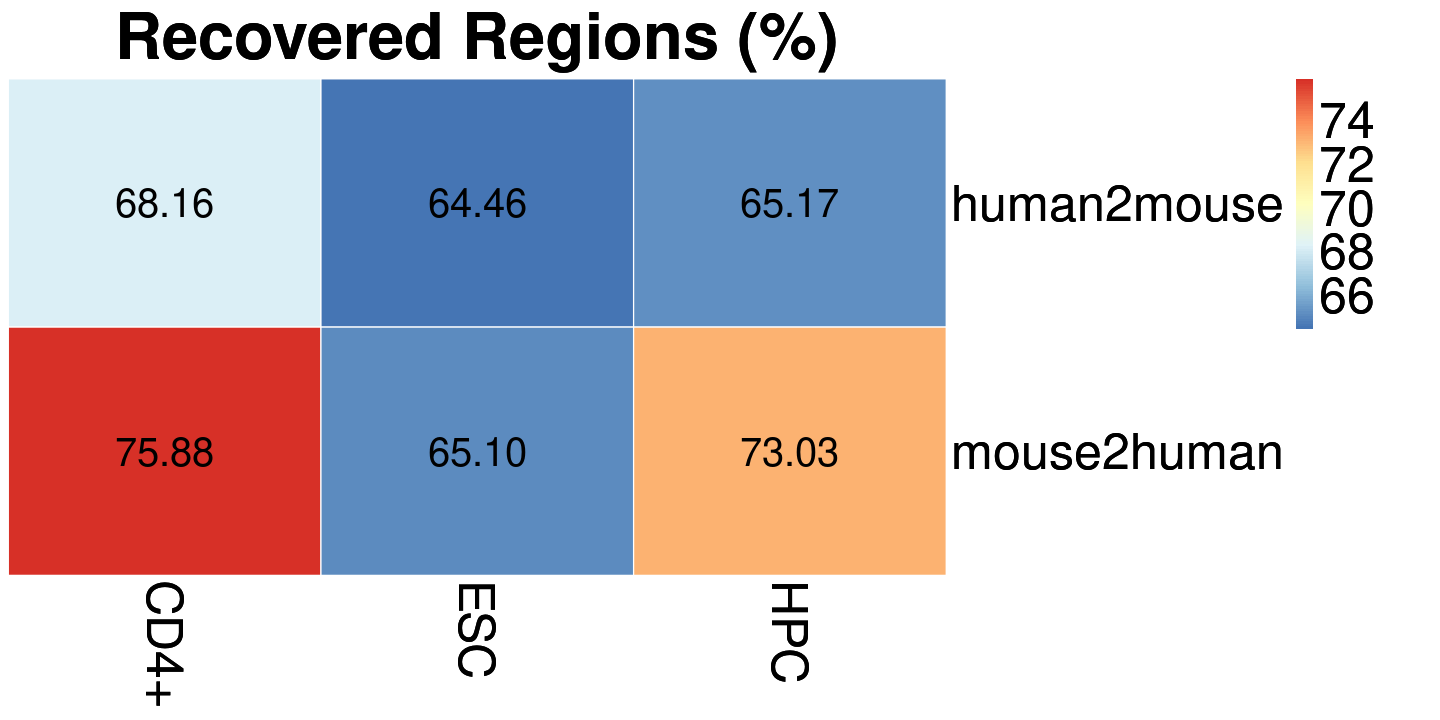

In [66]:
options(repr.plot.width=12, repr.plot.height=6)

percent_liftover_plot <- pheatmap(percent_liftover_wide_df, 
                                 cluster_rows = FALSE, 
                                 cluster_cols = FALSE,
                                 display_numbers = TRUE,
                                 number_color = "black",
                                 border_color = "white",
                                fontsize=30,
                                main = "Recovered Regions (%)")
percent_liftover_plot

In [67]:
ggsave(percent_liftover_plot, width = 12, height = 6,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/sample_percent_liftover_plot.pdf", 
       bg = "transparent")

ggsave(percent_liftover_plot, width = 12, height = 6,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/sample_percent_liftover_plot.png", 
       bg = "transparent")

In [68]:
percent_liftover_wide$liftover

[1] "human2mouse" "mouse2human"

# Session information

In [69]:
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /usr/lib64/libopenblasp-r0.3.3.so;  LAPACK version 3.8.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Denver
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 pheatmap_1.0.12    cowplot_1.1.3      ggplot2_3.5.1     
[5] data.table_1.16.2 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_1.8.9    dplyr_1.1.4       compiler_4.4.0   
 [5] crayon_1.5.3      tidyselect_1.2.1